# Fourier Motion Estimation Experiments

This notebook compares two Fourier-domain motion estimation methods:

1. **Phase / Prony Fourier Vision detector**  
   Estimates motion from per-frequency phase evolution.

2. **3D Fourier plane detector**  
   Estimates motion by scoring planes in the spatiotemporal Fourier volume.

We use synthetic videos with known ground-truth velocities and compare:

- clean one-object detection
- clean two-object detection
- closed-form vs Prony phase detection
- 3D plane detection
- robustness to noise
- number of frames
- velocity separation failure modes
- three-object behavior

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent 
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 13

from synthetic import (
    MovingObject,
    generate_synthetic_sequence,
)

from phase_model.segmenter import (
    FourierVisionConfig,
    FourierVisionSegmenter,
)

from plane_scoring_detection import FourierMotionDetector, FourierMotionConfig
PLANE_DETECTOR_AVAILABLE = True

In [3]:
def nearest_velocity_distance(estimated, target):
    if estimated is None or len(estimated) == 0:
        return np.inf

    target = np.asarray(target, dtype=float)

    return min(
        np.linalg.norm(np.asarray(v, dtype=float) - target)
        for v in estimated
    )


def mean_velocity_error(estimated, gt_velocities):
    return float(np.mean([
        nearest_velocity_distance(estimated, gt)
        for gt in gt_velocities
    ]))


def detection_rate(estimated, gt_velocities, tol=0.2):
    hits = [
        nearest_velocity_distance(estimated, gt) <= tol
        for gt in gt_velocities
    ]
    return float(np.mean(hits))


def velocity_error_table(results, gt_velocities, tol=0.2):
    rows = []

    for result in results:
        rows.append({
            "method": result["method"],
            "estimated_velocities": result["velocities"],
            "mean_error": mean_velocity_error(result["velocities"], gt_velocities),
            f"detection_rate@{tol}": detection_rate(result["velocities"], gt_velocities, tol=tol),
            "runtime_sec": result["runtime_sec"],
        })

    return pd.DataFrame(rows)

In [4]:
def plot_video_frames(video, frame_indices=None, title=None):
    if frame_indices is None:
        T = video.shape[0]
        frame_indices = [0, T // 2, T - 1]

    fig, axs = plt.subplots(1, len(frame_indices), figsize=(4 * len(frame_indices), 4))

    if len(frame_indices) == 1:
        axs = [axs]

    vmin = float(video.min())
    vmax = float(video.max())

    for ax, t in zip(axs, frame_indices):
        ax.imshow(video[t], cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(f"Frame {t}")
        ax.axis("off")

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()


def plot_velocity_map(
    ax,
    result,
    title=None,
    gt_velocities=None,
    show_legend=True,
):
    score_map = result["score_map"]
    vx_values = result["vx_values"]
    vy_values = result["vy_values"]
    estimated = result["velocities"]

    im = ax.imshow(
        score_map,
        origin="lower",
        extent=[
            vx_values[0],
            vx_values[-1],
            vy_values[0],
            vy_values[-1],
        ],
        aspect="auto",
    )

    if gt_velocities is not None:
        for vx, vy in gt_velocities:
            ax.scatter(
                vx,
                vy,
                marker="o",
                s=140,
                facecolors="none",
                edgecolors="white",
                linewidths=2.4,
                label="Ground truth",
            )

    if estimated is not None:
        for vx, vy in estimated:
            ax.scatter(
                vx,
                vy,
                marker="x",
                s=120,
                linewidths=2.4,
                color="red",
                label="Estimated",
            )

    ax.set_title(title if title is not None else result["method"])
    ax.set_xlabel(r"$v_x$ [pixels/frame]")
    ax.set_ylabel(r"$v_y$ [pixels/frame]")

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), loc="upper right", frameon=True)

    return im


def plot_multiple_velocity_maps(results, gt_velocities=None, figsize=None):
    n = len(results)

    if figsize is None:
        figsize = (5 * n, 4.5)

    fig, axs = plt.subplots(1, n, figsize=figsize, constrained_layout=True)

    if n == 1:
        axs = [axs]

    for ax, result in zip(axs, results):
        im = plot_velocity_map(
            ax,
            result,
            title=result["display_name"],
            gt_velocities=gt_velocities,
            show_legend=True,
        )

        label = result.get("score_label", "score")
        fig.colorbar(im, ax=ax, label=label)

    plt.show()

In [9]:
def run_phase_method(
    video,
    num_components,
    num_velocities,
    solver="prony",
    velocity_bounds=(-2.0, 2.0),
    velocity_bins=121,
    hough_sigma=0.08,
    peak_min_separation=25,
    min_frequency_radius=0.2,
):
    cfg = FourierVisionConfig(
        solver=solver,
        num_components=num_components,
        num_velocities=num_velocities,
        velocity_bounds=velocity_bounds,
        velocity_bins=velocity_bins,
        hough_sigma=hough_sigma,
        peak_min_separation=peak_min_separation,
        min_frequency_radius=min_frequency_radius,
        use_magnitude_weights=True,
    )

    detector = FourierVisionSegmenter(cfg)

    t0 = perf_counter()
    raw = detector.detect(video)
    runtime = perf_counter() - t0

    if solver == "closed_form_m2":
        display_name = "Phase closed-form"
    else:
        display_name = f"Phase Prony m={num_components}"

    return {
        "method": f"phase_{solver}",
        "display_name": display_name,
        "velocities": raw.velocities,
        "score_map": raw.hough,
        "vx_values": raw.vx_values,
        "vy_values": raw.vy_values,
        "score_label": "votes",
        "runtime_sec": runtime,
        "raw": raw,
    }


def run_plane_method(
    video,
    num_velocities,
    velocity_bounds=(-2.0, 2.0, 121),
    sigma=0.5,
    alpha=0.05,
    dc_bins=1,
    keep_frac=0.15,
    use_gpu=False,
):
    if not PLANE_DETECTOR_AVAILABLE:
        raise RuntimeError("3D plane detector is not available. Fix the import cell first.")

    cfg = FourierMotionConfig(
        velocity_bounds=velocity_bounds,
        sigma=sigma,
        alpha=alpha,
        dc_bins=dc_bins,
        keep_frac=keep_frac,
        use_gpu=use_gpu,
        use_hann_window=True,
        max_detections=num_velocities,
        min_detection_separation=8,
        verbose=False,
    )

    detector = FourierMotionDetector(cfg)

    t0 = perf_counter()
    raw = detector.detect(video)
    runtime = perf_counter() - t0

    velocity_grid = raw.velocity_grid

    return {
        "method": "3d_plane",
        "display_name": "3D Fourier plane",
        "velocities": [tuple(v) for v in raw.detected_velocities],
        "score_map": raw.energies,
        "vx_values": velocity_grid,
        "vy_values": velocity_grid,
        "score_label": "energy",
        "runtime_sec": runtime,
        "raw": raw,
    }

# Experiment 1: One Moving Object

This is a sanity check. There is only one translating Gaussian, so both methods should recover one velocity.

Ground truth velocities: [(1.0, 1.0)]


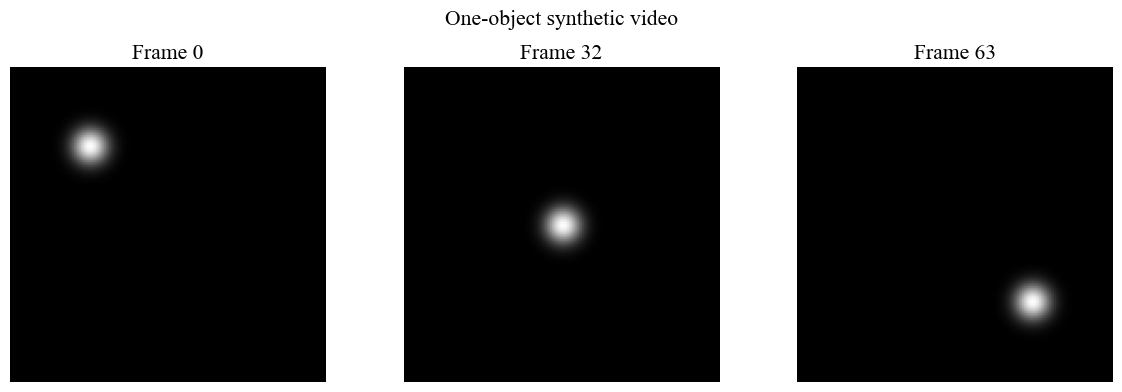

In [29]:
objects1 = [
    MovingObject(
        kind="gaussian",
        center=(32.0, 32.0),
        velocity=(1.0, 1.0),
        size=5.0,
        amplitude=1.0,
    )
]

video1, masks1, meta1 = generate_synthetic_sequence(
    T=64,
    H=128,
    W=128,
    objects=objects1,
    background=0.0,
    noise_std=0.0,
    normalize=False,
    clip=False,
    seed=0,
)

gt1 = meta1["velocities"]

print("Ground truth velocities:", gt1)
plot_video_frames(video1, title="One-object synthetic video")

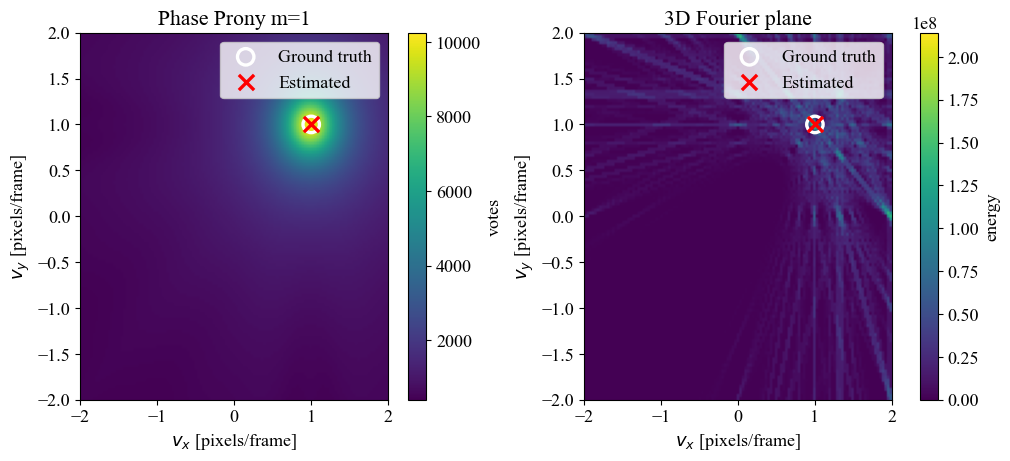

,method,estimated_velocities,mean_error,detection_rate@0.2,runtime_sec
0,phase_prony,"[(1.0, 1.0)]",0.0,1.0,5.751068
1,3d_plane,"[(1.0, 1.0)]",0.0,1.0,5.417476


In [30]:
phase1 = run_phase_method(
    video1,
    num_components=1,
    num_velocities=1,
    solver="prony",
    velocity_bounds=(-2.0, 2.0),
    velocity_bins=121,
    hough_sigma=0.06,
    peak_min_separation=25,
)

results1 = [phase1]

if PLANE_DETECTOR_AVAILABLE:
    plane1 = run_plane_method(
        video1,
        num_velocities=1,
        velocity_bounds=(-2.0, 2.0, 121),
        sigma=0.06,
        dc_bins=1,
    )
    results1.append(plane1)

plot_multiple_velocity_maps(results1, gt_velocities=gt1)
velocity_error_table(results1, gt1)